In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
from datetime import timedelta
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from statsmodels.tsa.api import Holt,SimpleExpSmoothing,ExponentialSmoothing
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
!pip install pystan
!pip install fbprophet
from fbprophet import Prophet
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
!pip install pmdarima
from pmdarima import auto_arima

In [ ]:
covid=pd.read_csv('/content/covid data.csv')
covid.tail(100)

,Sno.,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
285207,285208,05-02-2021,Tambov Oblast,Russia,03-05-2021 04:20,31632,477,29182
285208,285209,05-02-2021,Tamil Nadu,India,03-05-2021 04:20,1186344,14193,1054746
285209,285210,05-02-2021,Tarapaca,Chile,03-05-2021 04:20,33927,619,32319
285210,285211,05-02-2021,Tasmania,Australia,03-05-2021 04:20,234,13,221
285211,285212,05-02-2021,Tatarstan Republic,Russia,03-05-2021 04:20,20528,463,17604
...,...,...,...,...,...,...,...,...
285302,285303,05-02-2021,Zaporizhia Oblast,Ukraine,03-05-2021 04:20,96531,1919,78700
285303,285304,05-02-2021,Zeeland,Netherlands,03-05-2021 04:20,26045,233,0
285304,285305,05-02-2021,Zhejiang,Mainland China,03-05-2021 04:20,1344,1,1322
285305,285306,05-02-2021,Zhytomyr Oblast,Ukraine,03-05-2021 04:20,84641,1597,68529


In [ ]:
#Extracting India's data 
covid_india=covid[covid['Country/Region']=="India"]

#Extracting other countries for comparison of worst affected countries
covid_spain=covid[covid['Country/Region']=="Spain"]
covid_us=covid[covid['Country/Region']=="US"]
covid_italy=covid[covid['Country/Region']=="Italy"]
covid_iran=covid[covid['Country/Region']=="Iran"]
covid_france=covid[covid['Country/Region']=="France"]
covid_uk=covid[covid['Country/Region']=="UK"]
covid_br=covid[covid['Country/Region']=="Brazil"]
covid_russia=covid[covid['Country/Region']=="Russia"]

#Extracting data of neighbouring countries
covid_pak=covid[covid['Country/Region']=="Pakistan"]
covid_china=covid[covid['Country/Region']=="Mainland China"]
covid_afg=covid[covid['Country/Region']=="Afghanistan"]
covid_nepal=covid[covid['Country/Region']=="Nepal"]
covid_bhutan=covid[covid['Country/Region']=="Bhutan"]
covid_lanka=covid[covid["Country/Region"]=="Sri Lanka"]
covid_ban=covid[covid["Country/Region"]=="Bangladesh"]


In [ ]:
#Converting the date into Datetime format
covid_india["ObservationDate"]=pd.to_datetime(covid_india["ObservationDate"])
covid_spain["ObservationDate"]=pd.to_datetime(covid_spain["ObservationDate"])
covid_us["ObservationDate"]=pd.to_datetime(covid_us["ObservationDate"])
covid_italy["ObservationDate"]=pd.to_datetime(covid_italy["ObservationDate"])
covid_iran["ObservationDate"]=pd.to_datetime(covid_iran["ObservationDate"])
covid_france["ObservationDate"]=pd.to_datetime(covid_france["ObservationDate"])
covid_uk["ObservationDate"]=pd.to_datetime(covid_uk["ObservationDate"])
covid_br["ObservationDate"]=pd.to_datetime(covid_br["ObservationDate"])
covid_russia["ObservationDate"]=pd.to_datetime(covid_russia["ObservationDate"])

covid_pak["ObservationDate"]=pd.to_datetime(covid_pak["ObservationDate"])
covid_china["ObservationDate"]=pd.to_datetime(covid_china["ObservationDate"])
covid_afg["ObservationDate"]=pd.to_datetime(covid_afg["ObservationDate"])
covid_nepal["ObservationDate"]=pd.to_datetime(covid_nepal["ObservationDate"])
covid_bhutan["ObservationDate"]=pd.to_datetime(covid_bhutan["ObservationDate"])
covid_lanka["ObservationDate"]=pd.to_datetime(covid_lanka["ObservationDate"])
covid_ban["ObservationDate"]=pd.to_datetime(covid_ban["ObservationDate"])

In [ ]:
#Grouping the data based on the Date 
india_datewise=covid_india.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
spain_datewise=covid_spain.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
us_datewise=covid_us.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
italy_datewise=covid_italy.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
iran_datewise=covid_iran.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
france_datewise=covid_france.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
uk_datewise=covid_uk.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
brazil_datewise=covid_br.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
russia_datewise=covid_russia.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})

pak_datewise=covid_pak.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
china_datewise=covid_china.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
afg_datewise=covid_afg.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
nepal_datewise=covid_nepal.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
bhutan_datewise=covid_bhutan.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
lanka_datewise=covid_lanka.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
ban_datewise=covid_ban.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})

In [ ]:
#Adding week column to perfom weekly analysis further ahead
india_datewise["WeekofYear"]=india_datewise.index.weekofyear
spain_datewise["WeekofYear"]=spain_datewise.index.weekofyear
us_datewise["WeekofYear"]=us_datewise.index.weekofyear
italy_datewise["WeekofYear"]=italy_datewise.index.weekofyear
iran_datewise["WeekofYear"]=iran_datewise.index.weekofyear
france_datewise["WeekofYear"]=france_datewise.index.weekofyear
uk_datewise["WeekofYear"]=uk_datewise.index.weekofyear
brazil_datewise["WeekofYear"]=brazil_datewise.index.weekofyear
russia_datewise["WeekofYear"]=russia_datewise.index.weekofyear

pak_datewise["WeekofYear"]=pak_datewise.index.weekofyear
china_datewise["WeekofYear"]=china_datewise.index.weekofyear
afg_datewise["WeekofYear"]=afg_datewise.index.weekofyear
nepal_datewise["WeekofYear"]=nepal_datewise.index.weekofyear
bhutan_datewise["WeekofYear"]=bhutan_datewise.index.weekofyear
lanka_datewise["WeekofYear"]=lanka_datewise.index.weekofyear
ban_datewise["WeekofYear"]=ban_datewise.index.weekofyear
india_datewise["Days Since"]=(india_datewise.index-india_datewise.index[0])
india_datewise["Days Since"]=india_datewise["Days Since"].dt.days

In [ ]:
No_Lockdown=covid_india[covid_india["ObservationDate"]<pd.to_datetime("2020-03-21")]
Lockdown_1=covid_india[(covid_india["ObservationDate"]>=pd.to_datetime("2020-03-21"))&(covid_india["ObservationDate"]<pd.to_datetime("2020-04-15"))]
Lockdown_2=covid_india[(covid_india["ObservationDate"]>=pd.to_datetime("2020-04-15"))&(covid_india["ObservationDate"]<pd.to_datetime("2020-05-04"))]
Lockdown_3=covid_india[(covid_india["ObservationDate"]>=pd.to_datetime("2020-05-04"))&(covid_india["ObservationDate"]<pd.to_datetime("2020-05-19"))]
Lockdown_4=covid_india[(covid_india["ObservationDate"]>=pd.to_datetime("2020-05-19"))&(covid_india["ObservationDate"]<=pd.to_datetime("2020-05-31"))]
Unlock_1=covid_india[(covid_india["ObservationDate"]>=pd.to_datetime("2020-06-01"))&(covid_india["ObservationDate"]<=pd.to_datetime("2020-06-30"))]
Unlock_2=covid_india[(covid_india["ObservationDate"]>=pd.to_datetime("2020-07-01"))]

No_Lockdown_datewise=No_Lockdown.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
Lockdown_1_datewise=Lockdown_1.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
Lockdown_2_datewise=Lockdown_2.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
Lockdown_3_datewise=Lockdown_3.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
Lockdown_4_datewise=Lockdown_4.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
Unlock_1_datewise=Unlock_1.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})
Unlock_2_datewise=Unlock_2.groupby(["ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})

In [ ]:
covid["ObservationDate"]=pd.to_datetime(covid["ObservationDate"])
grouped_country=covid.groupby(["Country/Region","ObservationDate"]).agg({"Confirmed":'sum',"Recovered":'sum',"Deaths":'sum'})

In [ ]:
grouped_country["Active Cases"]=grouped_country["Confirmed"]-grouped_country["Recovered"]-grouped_country["Deaths"]
grouped_country["log_confirmed"]=np.log(grouped_country["Confirmed"])
grouped_country["log_active"]=np.log(grouped_country["Active Cases"])

In [ ]:
#Exploratory Data Analysis for India
print("Number of Confirmed Cases",india_datewise["Confirmed"].iloc[-1])
print("Number of Recovered Cases",india_datewise["Recovered"].iloc[-1])
print("Number of Death Cases",india_datewise["Deaths"].iloc[-1])
print("Number of Active Cases",india_datewise["Confirmed"].iloc[-1]-india_datewise["Recovered"].iloc[-1]-india_datewise["Deaths"].iloc[-1])
print("Number of Closed Cases",india_datewise["Recovered"].iloc[-1]+india_datewise["Deaths"].iloc[-1])
print("Approximate Number of Confirmed Cases per day",round(india_datewise["Confirmed"].iloc[-1]/india_datewise.shape[0]))
print("Approximate Number of Recovered Cases per day",round(india_datewise["Recovered"].iloc[-1]/india_datewise.shape[0]))
print("Approximate Number of Death Cases per day",round(india_datewise["Deaths"].iloc[-1]/india_datewise.shape[0]))
print("Number of New Cofirmed Cases in last 24 hours are",india_datewise["Confirmed"].iloc[-1]-india_datewise["Confirmed"].iloc[-2])
print("Number of New Recoverd Cases in last 24 hours are",india_datewise["Recovered"].iloc[-1]-india_datewise["Recovered"].iloc[-2])
print("Number of New Death Cases in last 24 hours are",india_datewise["Deaths"].iloc[-1]-india_datewise["Deaths"].iloc[-2])

Number of Confirmed Cases 19557457
Number of Recovered Cases 15992271
Number of Death Cases 215542
Number of Active Cases 3349644
Number of Closed Cases 16207813
Approximate Number of Confirmed Cases per day 42609
Approximate Number of Recovered Cases per day 34842
Approximate Number of Death Cases per day 470
Number of New Cofirmed Cases in last 24 hours are 0
Number of New Recoverd Cases in last 24 hours are 0
Number of New Death Cases in last 24 hours are 0


In [ ]:
fig=px.bar(x=india_datewise.index,y=india_datewise["Confirmed"]-india_datewise["Recovered"]-india_datewise["Deaths"])
fig.update_layout(title="Distribution of Number of Active Cases",
                  xaxis_title="Date",yaxis_title="Number of Cases",)
fig.show()

In [ ]:
fig=px.bar(x=india_datewise.index,y=india_datewise["Recovered"]+india_datewise["Deaths"])
fig.update_layout(title="Distribution of Number of Closed Cases",
                  xaxis_title="Date",yaxis_title="Number of Cases")
fig.show()

In [ ]:
#Growth Rate of Confirmed, Recoverd and Death Cases
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"],
                    mode='lines+markers',
                    name='Confirmed Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Recovered"],
                    mode='lines+markers',
                    name='Recovered Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Deaths"],
                    mode='lines+markers',
                    name='Death Cases'))
fig.update_layout(title="Growth of different types of cases in India",
                 xaxis_title="Date",yaxis_title="Number of Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()


In [ ]:
#Recovery and Mortality Rate
print('Mean Recovery Rate: ',((india_datewise["Recovered"]/india_datewise["Confirmed"])*100).mean())
print('Mean Mortality Rate: ',((india_datewise["Deaths"]/india_datewise["Confirmed"])*100).mean())
print('Median Recovery Rate: ',((india_datewise["Recovered"]/india_datewise["Confirmed"])*100).median())
print('Median Mortality Rate: ',((india_datewise["Deaths"]/india_datewise["Confirmed"])*100).median())

fig = make_subplots(rows=2, cols=1,
                   subplot_titles=("Recovery Rate", "Mortatlity Rate"))
fig.add_trace(
    go.Scatter(x=india_datewise.index, y=(india_datewise["Recovered"]/india_datewise["Confirmed"])*100,
              name="Recovery Rate"),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=india_datewise.index, y=(india_datewise["Deaths"]/india_datewise["Confirmed"])*100,
              name="Mortality Rate"),
    row=2, col=1
)
fig.update_layout(height=1000,legend=dict(x=-0.1,y=1.2,traceorder="normal"))
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_yaxes(title_text="Recovery Rate", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)
fig.update_yaxes(title_text="Mortality Rate", row=1, col=2)
fig.show()

Mean Recovery Rate:  68.66025772900409
Mean Mortality Rate:  1.7761987735829967
Median Recovery Rate:  82.1415964818023
Median Mortality Rate:  1.4990541905471788


In [ ]:
#Growth Factor for different types of Cases
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"]/india_datewise["Confirmed"].shift(),
                    mode='lines',
                    name='Growth Factor of Confirmed Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Recovered"]/india_datewise["Recovered"].shift(),
                    mode='lines',
                    name='Growth Factor of Recovered Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Deaths"]/india_datewise["Deaths"].shift(),
                    mode='lines',
                    name='Growth Factor of Death Cases'))
fig.update_layout(title="Datewise Growth Factor of different types of cases in India",
                 xaxis_title="Date",yaxis_title="Growth Factor",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
#Growth Factor for Active and Closed Cases
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, 
                        y=(india_datewise["Confirmed"]-india_datewise["Recovered"]-india_datewise["Deaths"])/(india_datewise["Confirmed"]-india_datewise["Recovered"]-india_datewise["Deaths"]).shift(),
                    mode='lines',
                    name='Growth Factor of Active Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=(india_datewise["Recovered"]+india_datewise["Deaths"])/(india_datewise["Recovered"]+india_datewise["Deaths"]).shift(),
                    mode='lines',
                    name='Growth Factor of Closed Cases'))
fig.update_layout(title="Datewise Growth Factor of Active and Closed cases in India",
                 xaxis_title="Date",yaxis_title="Growth Factor",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()


In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"].diff().fillna(0),
                    mode='lines+markers',
                    name='Confirmed Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Recovered"].diff().fillna(0),
                    mode='lines+markers',
                    name='Recovered Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Deaths"].diff().fillna(0),
                    mode='lines+markers',
                    name='Death Cases'))
fig.update_layout(title="Daily increase in different types of cases in India",
                 xaxis_title="Date",yaxis_title="Number of Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"].diff().rolling(window=7).mean(),
                    mode='lines+markers',
                    name='Confirmed Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Recovered"].diff().rolling(window=7).mean(),
                    mode='lines+markers',
                    name='Recovered Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Deaths"].diff().rolling(window=7).mean().diff(),
                    mode='lines+markers',
                    name='Death Cases'))
fig.update_layout(title="7 Days Rolling mean of Confirmed, Recovered and Death Cases",
                 xaxis_title="Date",yaxis_title="Number of Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=(india_datewise["Confirmed"]-india_datewise["Recovered"]-india_datewise["Deaths"]).diff().rolling(window=7).mean(),
                    mode='lines+markers',
                    name='Active Cases'))
fig.add_trace(go.Scatter(x=india_datewise.index, y=(india_datewise["Recovered"]+india_datewise["Deaths"]).diff().rolling(window=7).mean(),
                    mode='lines+markers',
                    name='Closed Cases'))
fig.update_layout(title="7 Days Rolling mean of Active and Closed Cases",
                 xaxis_title="Date",yaxis_title="Number of Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
week_num_india=[]
india_weekwise_confirmed=[]
india_weekwise_recovered=[]
india_weekwise_deaths=[]
w=1
for i in list(india_datewise["WeekofYear"].unique()):
    india_weekwise_confirmed.append(india_datewise[india_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    india_weekwise_recovered.append(india_datewise[india_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    india_weekwise_deaths.append(india_datewise[india_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_india.append(w)
    w=w+1

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=week_num_india, y=india_weekwise_confirmed,
                    mode='lines+markers',
                    name='Weekly Growth of Confirmed Cases'))
fig.add_trace(go.Scatter(x=week_num_india, y=india_weekwise_recovered,
                    mode='lines+markers',
                    name='Weekly Growth of Recovered Cases'))
fig.add_trace(go.Scatter(x=week_num_india, y=india_weekwise_deaths,
                    mode='lines+markers',
                    name='Weekly Growth of Death Cases'))
fig.update_layout(title="Weekly Growth of different types of Cases in India",
                 xaxis_title="Week Number",yaxis_title="Number of Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()


In [ ]:
print("Average weekly increase in number of Confirmed Cases",round(pd.Series(india_weekwise_confirmed).diff().fillna(0).mean()))
print("Average weekly increase in number of Recovered Cases",round(pd.Series(india_weekwise_recovered).diff().fillna(0).mean()))
print("Average weekly increase in number of Death Cases",round(pd.Series(india_weekwise_deaths).diff().fillna(0).mean()))

fig = make_subplots(rows=1, cols=2)
fig.add_trace(
    go.Bar(x=week_num_india, y=pd.Series(india_weekwise_confirmed).diff().fillna(0),
          name="Weekly rise in number of Confirmed Cases"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=week_num_india, y=pd.Series(india_weekwise_deaths).diff().fillna(0),
          name="Weekly rise in number of Death Cases"),
    row=1, col=2
)
fig.update_layout(title="India's Weekly increas in Number of Confirmed and Death Cases",
    font=dict(
        size=10,
    )
)
fig.update_layout(width=900,legend=dict(x=0,y=-0.5,traceorder="normal"))
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_yaxes(title_text="Number of Cases", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)
fig.update_yaxes(title_text="Number of Cases", row=1, col=2)
fig.show()

Average weekly increase in number of Confirmed Cases -1520
Average weekly increase in number of Recovered Cases -1878
Average weekly increase in number of Death Cases -13


In [ ]:
#Doubling Rate of COVID-19 Confirmed Cases

cases=100
double_days=[]
C=[]
while(1):
    double_days.append(int(india_datewise[india_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<india_datewise["Confirmed"].max()):
        continue
    else:
        break
        
cases=100
tipling_days=[]
C1=[]
while(1):
    tipling_days.append(int(india_datewise[india_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C1.append(cases)
    cases=cases*3
    if(cases<india_datewise["Confirmed"].max()):
        continue
    else:
        break
        
india_doubling=pd.DataFrame(list(zip(C,double_days)),columns=["No. of cases","Days since first case"])
india_doubling["Number of days required to Double the cases"]=india_doubling["Days since first case"].diff().fillna(india_doubling["Days since first case"].iloc[0])

india_tripling=pd.DataFrame(list(zip(C1,tipling_days)),columns=["No. of cases","Days since first case"])
india_tripling["Number of days required to Triple the cases"]=india_tripling["Days since first case"].diff().fillna(india_tripling["Days since first case"].iloc[0])

india_doubling.style.background_gradient(cmap='Reds')

,No. of cases,Days since first case,Number of days required to Double the cases
0,100,43,43.000000
1,200,49,6.000000
2,400,52,3.000000
3,800,56,4.000000
4,1600,61,5.000000
5,3200,65,4.000000
6,6400,69,4.000000
7,12800,76,7.000000
8,25600,85,9.000000
9,51200,96,11.000000


In [ ]:
#Lockdown Analysis for India

No_Lockdown_datewise["Active Cases"]=No_Lockdown_datewise["Confirmed"]-No_Lockdown_datewise["Recovered"]-No_Lockdown_datewise["Deaths"]
Lockdown_1_datewise["Active Cases"]=Lockdown_1_datewise["Confirmed"]-Lockdown_1_datewise["Recovered"]-Lockdown_1_datewise["Deaths"]
Lockdown_2_datewise["Active Cases"]=Lockdown_2_datewise["Confirmed"]-Lockdown_2_datewise["Recovered"]-Lockdown_2_datewise["Deaths"]
Lockdown_3_datewise["Active Cases"]=Lockdown_3_datewise["Confirmed"]-Lockdown_3_datewise["Recovered"]-Lockdown_3_datewise["Deaths"]
Lockdown_4_datewise["Active Cases"]=Lockdown_4_datewise["Confirmed"]-Lockdown_4_datewise["Recovered"]-Lockdown_4_datewise["Deaths"]
Unlock_1_datewise["Active Cases"]=Unlock_1_datewise["Confirmed"]-Unlock_1_datewise["Recovered"]-Unlock_1_datewise["Deaths"]
Unlock_2_datewise["Active Cases"]=Unlock_2_datewise["Confirmed"]-Unlock_2_datewise["Recovered"]-Unlock_2_datewise["Deaths"]


No_Lockdown_datewise["Days Since"]=(No_Lockdown_datewise.index-No_Lockdown_datewise.index.min()).days
Lockdown_1_datewise["Days Since"]=(Lockdown_1_datewise.index-Lockdown_1_datewise.index.min()).days
Lockdown_2_datewise["Days Since"]=(Lockdown_2_datewise.index-Lockdown_2_datewise.index.min()).days
Lockdown_3_datewise["Days Since"]=(Lockdown_3_datewise.index-Lockdown_3_datewise.index.min()).days
Lockdown_4_datewise["Days Since"]=(Lockdown_4_datewise.index-Lockdown_4_datewise.index.min()).days
Unlock_1_datewise["Days Since"]=(Unlock_1_datewise.index-Unlock_1_datewise.index.min()).days
Unlock_2_datewise["Days Since"]=(Unlock_2_datewise.index-Unlock_2_datewise.index.min()).days


cases=1
NL_doubling=[]
C=[]
while(1):
    NL_doubling.append(int(No_Lockdown_datewise[No_Lockdown_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<No_Lockdown_datewise["Confirmed"].max()):
        continue
    else:
        break
NL_Double_rate=pd.DataFrame(list(zip(C,NL_doubling)),columns=["No. of Cases","Days Since First Case"])
NL_Double_rate["Days required for Doubling"]=NL_Double_rate["Days Since First Case"].diff().fillna(NL_Double_rate["Days Since First Case"].iloc[0])

cases=Lockdown_1_datewise["Confirmed"].min()
L1_doubling=[]
C=[]
while(1):
    L1_doubling.append(int(Lockdown_1_datewise[Lockdown_1_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<Lockdown_1_datewise["Confirmed"].max()):
        continue
    else:
        break
L1_Double_rate=pd.DataFrame(list(zip(C,L1_doubling)),columns=["No. of Cases","Days Since Lockdown 1.0"])
L1_Double_rate["Days required for Doubling"]=L1_Double_rate["Days Since Lockdown 1.0"].diff().fillna(L1_Double_rate["Days Since Lockdown 1.0"].iloc[0])

cases=Lockdown_2_datewise["Confirmed"].min()
L2_doubling=[]
C=[]
while(1):
    L2_doubling.append(int(Lockdown_2_datewise[Lockdown_2_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<Lockdown_2_datewise["Confirmed"].max()):
        continue
    else:
        break
L2_Double_rate=pd.DataFrame(list(zip(C,L2_doubling)),columns=["No. of Cases","Days Since Lockdown 2.0"])
L2_Double_rate["Days required for Doubling"]=L2_Double_rate["Days Since Lockdown 2.0"].diff().fillna(L2_Double_rate["Days Since Lockdown 2.0"].iloc[0])

cases=Lockdown_3_datewise["Confirmed"].min()
L3_doubling=[]
C=[]
while(1):
    L3_doubling.append(int(Lockdown_3_datewise[Lockdown_3_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<Lockdown_3_datewise["Confirmed"].max()):
        continue
    else:
        break
L3_Double_rate=pd.DataFrame(list(zip(C,L3_doubling)),columns=["No. of Cases","Days Since Lockdown 3.0"])
L3_Double_rate["Days required for Doubling"]=L3_Double_rate["Days Since Lockdown 3.0"].diff().fillna(L3_Double_rate["Days Since Lockdown 3.0"].iloc[0])

cases=Lockdown_4_datewise["Confirmed"].min()
L4_doubling=[]
C=[]
while(1):
    L4_doubling.append(int(Lockdown_4_datewise[Lockdown_4_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<Lockdown_4_datewise["Confirmed"].max()):
        continue
    else:
        break
L4_Double_rate=pd.DataFrame(list(zip(C,L4_doubling)),columns=["No. of Cases","Days Since Lockdown 4.0"])
L4_Double_rate["Days required for Doubling"]=L4_Double_rate["Days Since Lockdown 4.0"].diff().fillna(L4_Double_rate["Days Since Lockdown 4.0"].iloc[0])

cases=Unlock_1_datewise["Confirmed"].min()
UL1_doubling=[]
C=[]
while(1):
    UL1_doubling.append(int(Unlock_1_datewise[Unlock_1_datewise["Confirmed"]<=cases].iloc[[-1]]["Days Since"]))
    C.append(cases)
    cases=cases*2
    if(cases<Unlock_1_datewise["Confirmed"].max()):
        continue
    else:
        break
UL1_Double_rate=pd.DataFrame(list(zip(C,UL1_doubling)),columns=["No. of Cases","Days Since Lockdown 4.0"])
UL1_Double_rate["Days required for Doubling"]=UL1_Double_rate["Days Since Lockdown 4.0"].diff().fillna(UL1_Double_rate["Days Since Lockdown 4.0"].iloc[0])

In [ ]:
print("Average Active Cases growth rate in Lockdown 1.0: ",(Lockdown_1_datewise["Active Cases"]/Lockdown_1_datewise["Active Cases"].shift()).mean())
print("Median Active Cases growth rate in Lockdown 1.0: ",(Lockdown_1_datewise["Active Cases"]/Lockdown_1_datewise["Active Cases"].shift()).median())
print("Average Active Cases growth rate in Lockdown 2.0: ",(Lockdown_2_datewise["Active Cases"]/Lockdown_2_datewise["Active Cases"].shift()).mean())
print("Median Active Cases growth rate in Lockdown 2.0: ",(Lockdown_2_datewise["Active Cases"]/Lockdown_2_datewise["Active Cases"].shift()).median())
print("Average Active Cases growth rate in Lockdown 3.0: ",(Lockdown_3_datewise["Active Cases"]/Lockdown_3_datewise["Active Cases"].shift()).mean())
print("Median Active Cases growth rate in Lockdown 3.0: ",(Lockdown_3_datewise["Active Cases"]/Lockdown_3_datewise["Active Cases"].shift()).median())
print("Average Active Cases growth rate in Lockdown 4.0: ",(Lockdown_4_datewise["Active Cases"]/Lockdown_4_datewise["Active Cases"].shift()).mean())
print("Median Active Cases growth rate in Lockdown 4.0: ",(Lockdown_4_datewise["Active Cases"]/Lockdown_4_datewise["Active Cases"].shift()).median())
print("Average Active Cases growth rate in Unlock 1.0: ",(Unlock_1_datewise["Active Cases"]/Unlock_1_datewise["Active Cases"].shift()).mean())
print("Median Active Cases growth rate in Unlock 1.0: ",(Unlock_1_datewise["Active Cases"]/Unlock_1_datewise["Active Cases"].shift()).median())


fig=go.Figure()
fig.add_trace(go.Scatter(y=list(Lockdown_1_datewise["Active Cases"]/Lockdown_1_datewise["Active Cases"].shift()),
                    mode='lines+markers',
                    name='Growth Factor of Lockdown 1.0 Active Cases'))
fig.add_trace(go.Scatter(y=list(Lockdown_2_datewise["Active Cases"]/Lockdown_2_datewise["Active Cases"].shift()),
                    mode='lines+markers',
                    name='Growth Factor of Lockdown 2.0 Active Cases'))
fig.add_trace(go.Scatter(y=list(Lockdown_3_datewise["Active Cases"]/Lockdown_3_datewise["Active Cases"].shift()),
                    mode='lines+markers',
                    name='Growth Factor of Lockdown 3.0 Active Cases'))
fig.add_trace(go.Scatter(y=list(Lockdown_4_datewise["Active Cases"]/Lockdown_4_datewise["Active Cases"].shift()),
                    mode='lines+markers',
                    name='Growth Factor of Lockdown 4.0 Active Cases'))
fig.add_trace(go.Scatter(y=list(Unlock_1_datewise["Active Cases"]/Unlock_1_datewise["Active Cases"].shift()),
                    mode='lines+markers',
                    name='Growth Factor of Unlock 1.0 Active Cases'))
# fig.add_trace(go.Scatter(y=list(Unlock_2_datewise["Active Cases"]/Unlock_2_datewise["Active Cases"].shift()),
#                     mode='lines+markers',
#                     name='Growth Factor of Unlock 2.0 Active Cases'))
fig.update_layout(title="Lockdownwise Growth Factor of Active Cases in India",
                 xaxis_title="Date",yaxis_title="Growth Factor",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

Average Active Cases growth rate in Lockdown 1.0:  1.1593835916264263
Median Active Cases growth rate in Lockdown 1.0:  1.1212799256202945
Average Active Cases growth rate in Lockdown 2.0:  1.0589658468208336
Median Active Cases growth rate in Lockdown 2.0:  1.055711195842128
Average Active Cases growth rate in Lockdown 3.0:  1.0433479599958473
Median Active Cases growth rate in Lockdown 3.0:  1.0438197911523128
Average Active Cases growth rate in Lockdown 4.0:  1.0366005332298471
Median Active Cases growth rate in Lockdown 4.0:  1.0443448437313414
Average Active Cases growth rate in Unlock 1.0:  1.0287584237095335
Median Active Cases growth rate in Unlock 1.0:  1.0281326187827924


In [ ]:
n_countries=["Pakistan","Mainland China","Afghanistan","Nepal","Bhutan","Sri Lanka","Bangladesh","India"]
comp_data=pd.concat([pak_datewise.iloc[[-1]],china_datewise.iloc[[-1]],afg_datewise.iloc[[-1]],nepal_datewise.iloc[[-1]],
          bhutan_datewise.iloc[[-1]],lanka_datewise.iloc[[-1]],ban_datewise.iloc[[-1]],india_datewise.iloc[[-1]]])
comp_data.drop(["Days Since","WeekofYear"],1,inplace=True)
comp_data.index=n_countries
comp_data["Mortality"]=(comp_data["Deaths"]/comp_data["Confirmed"])*100
comp_data["Recovery"]=(comp_data["Recovered"]/comp_data["Confirmed"])*100
comp_data["Survival Probability"]=(1-(comp_data["Deaths"]/comp_data["Confirmed"]))*100
comp_data.sort_values(["Confirmed"],ascending=False)
comp_data.style.background_gradient(cmap='Reds').format("{:.2f}")

,Confirmed,Recovered,Deaths,Mortality,Recovery,Survival Probability
Pakistan,834146.00,728044.00,18149.00,2.18,87.28,97.82
Mainland China,90697.00,85738.00,4636.00,5.11,94.53,94.89
Afghanistan,60122.00,53391.00,2637.00,4.39,88.80,95.61
Nepal,336030.00,283994.00,3325.00,0.99,84.51,99.01
Bhutan,1111.00,993.00,1.00,0.09,89.38,99.91
Sri Lanka,111753.00,97848.00,696.00,0.62,87.56,99.38
Bangladesh,761943.00,687328.00,11579.00,1.52,90.21,98.48
India,19557457.00,15992271.00,215542.00,1.10,81.77,98.90


In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=pak_datewise.index, y=np.log(pak_datewise["Confirmed"]),
                    mode='lines',name="Pakistan"))
fig.add_trace(go.Scatter(x=china_datewise.index, y=np.log(china_datewise["Confirmed"]),
                    mode='lines',name="China"))
fig.add_trace(go.Scatter(x=afg_datewise.index, y=np.log(afg_datewise["Confirmed"]),
                    mode='lines',name="Afghanistan"))
fig.add_trace(go.Scatter(x=nepal_datewise.index, y=np.log(nepal_datewise["Confirmed"]),
                    mode='lines',name="Nepal"))
fig.add_trace(go.Scatter(x=bhutan_datewise.index, y=np.log(bhutan_datewise["Confirmed"]),
                    mode='lines',name="Bhutan"))
fig.add_trace(go.Scatter(x=lanka_datewise.index, y=np.log(lanka_datewise["Confirmed"]),
                    mode='lines',name="Sri-Lanka"))
fig.add_trace(go.Scatter(x=ban_datewise.index, y=np.log(ban_datewise["Confirmed"]),
                    mode='lines',name="Bangladesh"))
fig.add_trace(go.Scatter(x=india_datewise.index, y=np.log(india_datewise["Confirmed"]),
                    mode='lines',name="India"))
fig.update_layout(title="Confirmed Cases plot for Neighbouring Countries of India (Logarithmic Scale)",
                  xaxis_title="Date",yaxis_title="Number of Cases (Log scale)",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
fig=go.Figure()
for country in n_countries:
    fig.add_trace(go.Scatter(x=grouped_country.loc[country]["log_confirmed"], y=grouped_country.loc[country]["log_active"],
                    mode='lines',name=country))
fig.update_layout(height=600,title="COVID-19 Journey of India's Neighbouring countries",
                 xaxis_title="Confirmed Cases (Logrithmic Scale)",yaxis_title="Active Cases (Logarithmic Scale)",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()


In [ ]:
fig=go.Figure()
for country in n_countries:
    fig.add_trace(go.Scatter(x=grouped_country.loc[country].index, y=grouped_country.loc[country]["Confirmed"].rolling(window=7).mean().diff(),
                    mode='lines',name=country))
fig.update_layout(title="7 Days Rolling Average of Daily increase of Confirmed Cases for Neighbouring Countries",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()


In [ ]:
fig=go.Figure()
for country in n_countries:
    fig.add_trace(go.Scatter(x=grouped_country.loc[country].index, y=grouped_country.loc[country]["Deaths"].rolling(window=7).mean().diff(),
                    mode='lines',name=country))
fig.update_layout(title="7 Days Rolling Average of Daily increase of Death Cases for Neighbouring Countries",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
fig = px.pie(comp_data, values='Confirmed', names=comp_data.index, 
             title='Proportion of Confirmed Cases in India and among Neighbouring countries ')
fig.show()


In [ ]:
fig = px.pie(comp_data, values='Recovered', names=comp_data.index, 
             title='Proportion of Recovered Cases in India and among Neighbouring countries ')
fig.show()

In [ ]:
week_num_spain=[]
spain_weekwise_confirmed=[]
spain_weekwise_recovered=[]
spain_weekwise_deaths=[]
w=1
for i in list(spain_datewise["WeekofYear"].unique()):
    spain_weekwise_confirmed.append(spain_datewise[spain_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    spain_weekwise_recovered.append(spain_datewise[spain_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    spain_weekwise_deaths.append(spain_datewise[spain_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_spain.append(w)
    w=w+1

week_num_us=[]
us_weekwise_confirmed=[]
us_weekwise_recovered=[]
us_weekwise_deaths=[]
w=1
for i in list(us_datewise["WeekofYear"].unique()):
    us_weekwise_confirmed.append(us_datewise[us_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    us_weekwise_recovered.append(us_datewise[us_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    us_weekwise_deaths.append(us_datewise[us_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_us.append(w)
    w=w+1

week_num_italy=[]
italy_weekwise_confirmed=[]
italy_weekwise_recovered=[]
italy_weekwise_deaths=[]
w=1
for i in list(italy_datewise["WeekofYear"].unique()):
    italy_weekwise_confirmed.append(italy_datewise[italy_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    italy_weekwise_recovered.append(italy_datewise[italy_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    italy_weekwise_deaths.append(italy_datewise[italy_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_italy.append(w)
    w=w+1
    
week_num_iran=[]
iran_weekwise_confirmed=[]
iran_weekwise_recovered=[]
iran_weekwise_deaths=[]
w=1
for i in list(iran_datewise["WeekofYear"].unique()):
    iran_weekwise_confirmed.append(iran_datewise[iran_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    iran_weekwise_recovered.append(iran_datewise[iran_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    iran_weekwise_deaths.append(iran_datewise[iran_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_iran.append(w)
    w=w+1
    
week_num_france=[]
france_weekwise_confirmed=[]
france_weekwise_recovered=[]
france_weekwise_deaths=[]
w=1
for i in list(france_datewise["WeekofYear"].unique()):
    france_weekwise_confirmed.append(france_datewise[france_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    france_weekwise_recovered.append(france_datewise[france_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    france_weekwise_deaths.append(france_datewise[france_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_france.append(w)
    w=w+1
    
week_num_uk=[]
uk_weekwise_confirmed=[]
uk_weekwise_recovered=[]
uk_weekwise_deaths=[]
w=1
for i in list(uk_datewise["WeekofYear"].unique()):
    uk_weekwise_confirmed.append(uk_datewise[uk_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    uk_weekwise_recovered.append(uk_datewise[uk_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    uk_weekwise_deaths.append(uk_datewise[uk_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_uk.append(w)
    w=w+1
    
week_num_br=[]
br_weekwise_confirmed=[]
br_weekwise_recovered=[]
br_weekwise_deaths=[]
w=1
for i in list(brazil_datewise["WeekofYear"].unique()):
    br_weekwise_confirmed.append(brazil_datewise[brazil_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    br_weekwise_recovered.append(brazil_datewise[brazil_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    br_weekwise_deaths.append(brazil_datewise[brazil_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_br.append(w)
    w=w+1
    
week_num_rus=[]
rus_weekwise_confirmed=[]
rus_weekwise_recovered=[]
rus_weekwise_deaths=[]
w=1
for i in list(russia_datewise["WeekofYear"].unique()):
    rus_weekwise_confirmed.append(russia_datewise[russia_datewise["WeekofYear"]==i]["Confirmed"].iloc[-1])
    rus_weekwise_recovered.append(russia_datewise[russia_datewise["WeekofYear"]==i]["Recovered"].iloc[-1])
    rus_weekwise_deaths.append(russia_datewise[russia_datewise["WeekofYear"]==i]["Deaths"].iloc[-1])
    week_num_rus.append(w)
    w=w+1

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=week_num_spain, y=spain_weekwise_confirmed,
                    mode='lines+markers',name="Spain"))
fig.add_trace(go.Scatter(x=week_num_us, y=us_weekwise_confirmed,
                    mode='lines+markers',name="USA"))
fig.add_trace(go.Scatter(x=week_num_italy, y=italy_weekwise_confirmed,
                    mode='lines+markers',name="Italy"))
fig.add_trace(go.Scatter(x=week_num_iran, y=iran_weekwise_confirmed,
                    mode='lines+markers',name="Iran"))
fig.add_trace(go.Scatter(x=week_num_france, y=france_weekwise_confirmed,
                    mode='lines+markers',name="France"))
fig.add_trace(go.Scatter(x=week_num_uk, y=uk_weekwise_confirmed,
                    mode='lines+markers',name="United Kingdom"))
fig.add_trace(go.Scatter(x=week_num_br, y=br_weekwise_confirmed,
                    mode='lines+markers',name="Brazil"))
fig.add_trace(go.Scatter(x=week_num_rus, y=rus_weekwise_confirmed,
                    mode='lines+markers',name="Russia"))
fig.add_trace(go.Scatter(x=week_num_india, y=india_weekwise_confirmed,
                    mode='lines+markers',name="India"))
fig.update_layout(title="Weekly Growth of Confirmed Cases",
                 xaxis_title="Date",yaxis_title="Number of Confirmed Cases",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=week_num_spain, y=spain_weekwise_deaths,
                    mode='lines+markers',name="Spain"))
fig.add_trace(go.Scatter(x=week_num_us, y=us_weekwise_deaths,
                    mode='lines+markers',name="USA"))
fig.add_trace(go.Scatter(x=week_num_italy, y=italy_weekwise_deaths,
                    mode='lines+markers',name="Italy"))
fig.add_trace(go.Scatter(x=week_num_iran, y=iran_weekwise_deaths,
                    mode='lines+markers',name="Iran"))
fig.add_trace(go.Scatter(x=week_num_france, y=france_weekwise_deaths,
                    mode='lines+markers',name="France"))
fig.add_trace(go.Scatter(x=week_num_uk, y=uk_weekwise_deaths,
                    mode='lines+markers',name="United Kingdom"))
fig.add_trace(go.Scatter(x=week_num_br, y=br_weekwise_deaths,
                    mode='lines+markers',name="Brazil"))
fig.add_trace(go.Scatter(x=week_num_rus, y=rus_weekwise_deaths,
                    mode='lines+markers',name="Russia"))
fig.add_trace(go.Scatter(x=week_num_india, y=india_weekwise_deaths,
                    mode='lines+markers',name="India"))
fig.update_layout(title="Weekly Growth of Death Cases",
                 xaxis_title="Date",yaxis_title="Number of Death Cases",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
#machine learning predictions

#Polynomial regression
train_ml=india_datewise.iloc[:int(india_datewise.shape[0]*0.95)]
valid_ml=india_datewise.iloc[int(india_datewise.shape[0]*0.95):]
model_scores=[]

In [ ]:
poly = PolynomialFeatures(degree = 6) 

In [ ]:
train_poly=poly.fit_transform(np.array(train_ml["Days Since"]).reshape(-1,1))
valid_poly=poly.fit_transform(np.array(valid_ml["Days Since"]).reshape(-1,1))
y=train_ml["Confirmed"]
linreg=LinearRegression(normalize=True)
linreg.fit(train_poly,y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

In [ ]:
prediction_poly=linreg.predict(valid_poly)
rmse_poly=np.sqrt(mean_squared_error(valid_ml["Confirmed"],prediction_poly))


In [ ]:
rmspe = (np.sqrt(np.mean(np.square((valid_ml["Confirmed"] - prediction_poly) / valid_ml["Confirmed"])))) * 100
model_scores.append(rmspe)
rmspe


5.873850452388137

In [ ]:
comp_data=poly.fit_transform(np.array(india_datewise["Days Since"]).reshape(-1,1))
plt.figure(figsize=(11,11))
predictions_poly=linreg.predict(comp_data)
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=india_datewise.index, y=predictions_poly,
                    mode='lines',name="Polynomial Regression Best Fit",
                    line=dict(color='black', dash='dot')))
fig.update_layout(title="Confirmed Cases Polynomial Regression Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()


<Figure size 792x792 with 0 Axes>

In [ ]:
new_date=[]
new_prediction_poly=[]
for i in range(1,100):
    new_date.append(india_datewise.index[-1]+timedelta(days=i))
    new_date_poly=poly.fit_transform(np.array(india_datewise["Days Since"].max()+i).reshape(-1,1))
    new_prediction_poly.append(linreg.predict(new_date_poly)[0])
model_predictions=pd.DataFrame(zip(new_date,new_prediction_poly),columns=["Date","Polynomial Regression Prediction"])
model_predictions.tail(10)

,Date,Polynomial Regression Prediction
89,2021-07-31,1.008490e+08
90,2021-08-01,1.028079e+08
91,2021-08-02,1.048001e+08
92,2021-08-03,1.068259e+08
93,2021-08-04,1.088858e+08
94,2021-08-05,1.109802e+08
95,2021-08-06,1.131096e+08
96,2021-08-07,1.152742e+08
97,2021-08-08,1.174747e+08
98,2021-08-09,1.197114e+08


In [ ]:
comp_data=poly.fit_transform(np.array(india_datewise["Days Since"]).reshape(-1,1))
plt.figure(figsize=(11,11))
predictions_poly=linreg.predict(comp_data)
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=india_datewise.index, y=predictions_poly,
                    mode='lines',name="Polynomial Regression Best Fit",
                    line=dict(color='black', dash='dot')))
fig.add_trace(go.Scatter(x=new_date, y=new_prediction_poly, mode='lines+markers',name='Predicted'))
fig.update_layout(title="Confirmed Cases Polynomial Regression Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",
                 legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

<Figure size 792x792 with 0 Axes>

In [ ]:
#SVM

train_ml=india_datewise.iloc[:int(india_datewise.shape[0]*0.95)]
valid_ml=india_datewise.iloc[int(india_datewise.shape[0]*0.95):]
svm=SVR(C=0.01,degree=7,kernel='poly')
svm.fit(np.array(train_ml["Days Since"]).reshape(-1,1),train_ml["Confirmed"])

SVR(C=0.01, cache_size=200, coef0=0.0, degree=7, epsilon=0.1, gamma='scale',
    kernel='poly', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [ ]:
prediction_svm=svm.predict(np.array(valid_ml["Days Since"]).reshape(-1,1))
rmse_svm=np.sqrt(mean_squared_error(valid_ml["Confirmed"],prediction_svm))
model_scores.append(rmse_svm)
print("Root Mean Square Error for SVR Model: ",rmse_svm)

Root Mean Square Error for SVR Model:  654419.6906581729


In [ ]:
rmspe = (np.sqrt(np.mean(np.square((valid_ml["Confirmed"] - prediction_svm) / valid_ml["Confirmed"])))) * 100
model_scores.append(rmspe)
rmspe


4.239035644934274

In [ ]:
plt.figure(figsize=(11,6))
predictions=svm.predict(np.array(india_datewise["Days Since"]).reshape(-1,1))
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=india_datewise.index, y=predictions,
                    mode='lines',name="Support Vector Machine Best fit Kernel",
                    line=dict(color='black', dash='dot')))
fig.update_layout(title="Confirmed Cases Support Vector Machine Regressor Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

<Figure size 792x432 with 0 Axes>

In [ ]:
new_date=[]
new_prediction_svm=[]
for i in range(1,100):
    new_date.append(india_datewise.index[-1]+timedelta(days=i))
    new_prediction_svm.append(svm.predict(np.array(india_datewise["Days Since"].max()+i).reshape(-1,1))[0])
model_predictions["SVM Prediction"]=new_prediction_svm
model_predictions.tail(10)

,Date,Polynomial Regression Prediction,SVM Prediction
89,2021-07-31,1.008490e+08,5.842562e+07
90,2021-08-01,1.028079e+08,5.913766e+07
91,2021-08-02,1.048001e+08,5.985751e+07
92,2021-08-03,1.068259e+08,6.058526e+07
93,2021-08-04,1.088858e+08,6.132098e+07
94,2021-08-05,1.109802e+08,6.206475e+07
95,2021-08-06,1.131096e+08,6.281662e+07
96,2021-08-07,1.152742e+08,6.357668e+07
97,2021-08-08,1.174747e+08,6.434501e+07
98,2021-08-09,1.197114e+08,6.512167e+07


In [ ]:
plt.figure(figsize=(11,11))
predictions=svm.predict(np.array(india_datewise["Days Since"]).reshape(-1,1))
fig=go.Figure()
fig.add_trace(go.Scatter(x=india_datewise.index, y=india_datewise["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=india_datewise.index, y=predictions,
                    mode='lines',name="Support Vector Machine Best fit Kernel",
                    line=dict(color='black', dash='dot')))
fig.add_trace(go.Scatter(x=new_date, y=new_prediction_svm, mode='lines+markers', name='Predicted'))
fig.update_layout(title="Confirmed Cases Support Vector Machine Regressor Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

<Figure size 792x792 with 0 Axes>

In [ ]:
#Time series

#AR model using ARIMA 

model_train=india_datewise.iloc[:int(india_datewise.shape[0]*0.95)]
valid=india_datewise.iloc[int(india_datewise.shape[0]*0.95):]
y_pred=valid.copy()

In [ ]:
model_ar= auto_arima(model_train["Confirmed"],trace=True, error_action='ignore', start_p=0,start_q=0,max_p=3,max_q=0,
                   suppress_warnings=True,stepwise=False,seasonal=False)
model_ar.fit(model_train["Confirmed"])

 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=9438.733, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=9260.445, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=9209.816, Time=0.06 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=9194.788, Time=0.09 sec

Best model:  ARIMA(3,2,0)(0,0,0)[0] intercept
Total fit time: 0.193 seconds


ARIMA(maxiter=50, method='lbfgs', order=(3, 2, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

In [ ]:
prediction_ar=model_ar.predict(len(valid))
y_pred["AR Model Prediction"]=prediction_ar

In [ ]:
model_scores.append(np.sqrt(mean_squared_error(y_pred["Confirmed"],y_pred["AR Model Prediction"])))
print("Root Mean Square Error for AR Model: ",np.sqrt(mean_squared_error(y_pred["Confirmed"],y_pred["AR Model Prediction"])))

Root Mean Square Error for AR Model:  1718256.252491195


In [ ]:
rmspe = (np.sqrt(np.mean(np.square((valid["Confirmed"] - y_pred["AR Model Prediction"]) / valid["Confirmed"])))) * 100
model_scores.append(rmspe)
rmspe


9.380581180967356

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=model_train.index, y=model_train["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=valid.index, y=valid["Confirmed"],
                    mode='lines+markers',name="Validation Data for Confirmed Cases",))
fig.add_trace(go.Scatter(x=valid.index, y=y_pred["AR Model Prediction"],
                    mode='lines+markers',name="Prediction of Confirmed Cases",))
fig.update_layout(title="Confirmed Cases AR Model Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
AR_model_new_prediction=[]
for i in range(1,100):
    AR_model_new_prediction.append(model_ar.predict(len(valid)+i)[-1])
model_predictions["AR Model Prediction"]=AR_model_new_prediction
model_predictions.tail(10)

,Date,Polynomial Regression Prediction,SVM Prediction,AR Model Prediction
89,2021-07-31,1.008490e+08,5.842562e+07,3.050557e+07
90,2021-08-01,1.028079e+08,5.913766e+07,3.067656e+07
91,2021-08-02,1.048001e+08,5.985751e+07,3.084787e+07
92,2021-08-03,1.068259e+08,6.058526e+07,3.101949e+07
93,2021-08-04,1.088858e+08,6.132098e+07,3.119142e+07
94,2021-08-05,1.109802e+08,6.206475e+07,3.136367e+07
95,2021-08-06,1.131096e+08,6.281662e+07,3.153623e+07
96,2021-08-07,1.152742e+08,6.357668e+07,3.170910e+07
97,2021-08-08,1.174747e+08,6.434501e+07,3.188229e+07
98,2021-08-09,1.197114e+08,6.512167e+07,3.205579e+07


In [ ]:
model_train=india_datewise.iloc[:int(india_datewise.shape[0]*0.95)]
valid=india_datewise.iloc[int(india_datewise.shape[0]*0.95):]
y_pred=valid.copy()


In [ ]:
model_ma= auto_arima(model_train["Confirmed"],trace=True, error_action='ignore', start_p=0,start_q=0,max_p=0,max_q=5,
                   suppress_warnings=True,stepwise=False,seasonal=False)
model_ma.fit(model_train["Confirmed"])

 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=9438.733, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=9214.330, Time=0.22 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=9199.550, Time=0.10 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=9196.081, Time=0.19 sec
 ARIMA(0,2,4)(0,0,0)[0] intercept   : AIC=9170.056, Time=0.29 sec
 ARIMA(0,2,5)(0,0,0)[0] intercept   : AIC=9157.417, Time=0.30 sec

Best model:  ARIMA(0,2,5)(0,0,0)[0] intercept
Total fit time: 1.142 seconds


ARIMA(maxiter=50, method='lbfgs', order=(0, 2, 5), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

In [ ]:
prediction_ma=model_ma.predict(len(valid))
y_pred["MA Model Prediction"]=prediction_ma

In [ ]:
model_scores.append(np.sqrt(mean_squared_error(y_pred["Confirmed"],y_pred["MA Model Prediction"])))
print("Root Mean Square Error for MA Model: ",np.sqrt(mean_squared_error(y_pred["Confirmed"],y_pred["MA Model Prediction"])))

Root Mean Square Error for MA Model:  1421911.7750652626


In [ ]:
rmspe = (np.sqrt(np.mean(np.square((valid["Confirmed"] - y_pred["MA Model Prediction"]) / valid["Confirmed"])))) * 100
model_scores.append(rmspe)
rmspe

7.737991272265246

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=model_train.index, y=model_train["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=valid.index, y=valid["Confirmed"],
                    mode='lines+markers',name="Validation Data for Confirmed Cases",))
fig.add_trace(go.Scatter(x=valid.index, y=y_pred["MA Model Prediction"],
                    mode='lines+markers',name="Prediction for Confirmed Cases",))
fig.update_layout(title="Confirmed Cases MA Model Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
MA_model_new_prediction=[]
for i in range(1,100):
    MA_model_new_prediction.append(model_ma.predict(len(valid)+i)[-1])
model_predictions["MA Model Prediction"]=MA_model_new_prediction
model_predictions.tail(10)

,Date,Polynomial Regression Prediction,SVM Prediction,AR Model Prediction,MA Model Prediction
89,2021-07-31,1.008490e+08,5.842562e+07,3.050557e+07,3.553037e+07
90,2021-08-01,1.028079e+08,5.913766e+07,3.067656e+07,3.577083e+07
91,2021-08-02,1.048001e+08,5.985751e+07,3.084787e+07,3.601204e+07
92,2021-08-03,1.068259e+08,6.058526e+07,3.101949e+07,3.625400e+07
93,2021-08-04,1.088858e+08,6.132098e+07,3.119142e+07,3.649670e+07
94,2021-08-05,1.109802e+08,6.206475e+07,3.136367e+07,3.674015e+07
95,2021-08-06,1.131096e+08,6.281662e+07,3.153623e+07,3.698434e+07
96,2021-08-07,1.152742e+08,6.357668e+07,3.170910e+07,3.722928e+07
97,2021-08-08,1.174747e+08,6.434501e+07,3.188229e+07,3.747497e+07
98,2021-08-09,1.197114e+08,6.512167e+07,3.205579e+07,3.772140e+07


In [ ]:
#ARIMA model

model_train=india_datewise.iloc[:int(india_datewise.shape[0]*0.95)]
valid=india_datewise.iloc[int(india_datewise.shape[0]*0.95):]
y_pred=valid.copy()


In [ ]:
model_arima= auto_arima(model_train["Confirmed"],trace=True, error_action='ignore', start_p=1,start_q=1,max_p=3,max_q=3,
                   suppress_warnings=True,stepwise=False,seasonal=False)
model_arima.fit(model_train["Confirmed"])

 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=9438.733, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=9214.330, Time=0.22 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=9199.550, Time=0.10 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=9196.081, Time=0.19 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=9260.445, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=9197.348, Time=0.09 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=9201.211, Time=0.19 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=9193.210, Time=0.57 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=9209.816, Time=0.06 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=9194.280, Time=0.11 sec
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=9196.922, Time=0.59 sec
 ARIMA(2,2,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.24 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=9194.788, Time=0.10 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=9193.949, Time=0.20 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=9196.225, Time=0.45 sec

Best model:  A

ARIMA(maxiter=50, method='lbfgs', order=(1, 2, 3), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

In [ ]:
prediction_arima=model_arima.predict(len(valid))
y_pred["ARIMA Model Prediction"]=prediction_arima

In [ ]:
model_scores.append(np.sqrt(mean_squared_error(y_pred["Confirmed"],y_pred["ARIMA Model Prediction"])))
print("Root Mean Square Error for MA Model: ",np.sqrt(mean_squared_error(y_pred["Confirmed"],y_pred["ARIMA Model Prediction"])))

Root Mean Square Error for MA Model:  1719761.8897487444


In [ ]:
rmspe = (np.sqrt(np.mean(np.square((valid["Confirmed"] - y_pred["ARIMA Model Prediction"]) / valid["Confirmed"])))) * 100
model_scores.append(rmspe)
rmspe

9.393528895014363

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=model_train.index, y=model_train["Confirmed"],
                    mode='lines+markers',name="Train Data for Confirmed Cases"))
fig.add_trace(go.Scatter(x=valid.index, y=valid["Confirmed"],
                    mode='lines+markers',name="Validation Data for Confirmed Cases",))
fig.add_trace(go.Scatter(x=valid.index, y=y_pred["ARIMA Model Prediction"],
                    mode='lines+markers',name="Prediction for Confirmed Cases",))
fig.update_layout(title="Confirmed Cases ARIMA Model Prediction",
                 xaxis_title="Date",yaxis_title="Confirmed Cases",legend=dict(x=0,y=1,traceorder="normal"))
fig.show()

In [ ]:
ARIMA_model_new_prediction=[]
for i in range(1,100):
    ARIMA_model_new_prediction.append(model_arima.predict(len(valid)+i)[-1])
model_predictions["ARIMA Model Prediction"]=ARIMA_model_new_prediction
model_predictions.tail(10)

,Date,Polynomial Regression Prediction,SVM Prediction,AR Model Prediction,MA Model Prediction,ARIMA Model Prediction
89,2021-07-31,1.008490e+08,5.842562e+07,3.050557e+07,3.553037e+07,3.138943e+07
90,2021-08-01,1.028079e+08,5.913766e+07,3.067656e+07,3.577083e+07,3.157770e+07
91,2021-08-02,1.048001e+08,5.985751e+07,3.084787e+07,3.601204e+07,3.176646e+07
92,2021-08-03,1.068259e+08,6.058526e+07,3.101949e+07,3.625400e+07,3.195569e+07
93,2021-08-04,1.088858e+08,6.132098e+07,3.119142e+07,3.649670e+07,3.214540e+07
94,2021-08-05,1.109802e+08,6.206475e+07,3.136367e+07,3.674015e+07,3.233559e+07
95,2021-08-06,1.131096e+08,6.281662e+07,3.153623e+07,3.698434e+07,3.252626e+07
96,2021-08-07,1.152742e+08,6.357668e+07,3.170910e+07,3.722928e+07,3.271741e+07
97,2021-08-08,1.174747e+08,6.434501e+07,3.188229e+07,3.747497e+07,3.290904e+07
98,2021-08-09,1.197114e+08,6.512167e+07,3.205579e+07,3.772140e+07,3.310114e+07


In [ ]:
#fb prophet

covid.head()


,Sno.,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,2020-01-22,Anhui,Mainland China,1/22/2020 17:00,1,0,0
1,2,2020-01-22,Beijing,Mainland China,1/22/2020 17:00,14,0,0
2,3,2020-01-22,Chongqing,Mainland China,1/22/2020 17:00,6,0,0
3,4,2020-01-22,Fujian,Mainland China,1/22/2020 17:00,1,0,0
4,5,2020-01-22,Gansu,Mainland China,1/22/2020 17:00,0,0,0


In [ ]:
X=covid[['ObservationDate', 'Province/State', 'Country/Region']]
Y=covid[['Confirmed']]

In [ ]:
prophet=pd.DataFrame()
prophet['ds']=pd.to_datetime(X["ObservationDate"])
prophet['y']=Y
prophet.tail(100)

,ds,y
285207,2021-05-02,31632
285208,2021-05-02,1186344
285209,2021-05-02,33927
285210,2021-05-02,234
285211,2021-05-02,20528
...,...,...
285302,2021-05-02,96531
285303,2021-05-02,26045
285304,2021-05-02,1344
285305,2021-05-02,84641


In [ ]:
prophet_basic=Prophet(interval_width=0.95,weekly_seasonality=True)
prophet_basic.fit(prophet)
future= prophet_basic.make_future_dataframe(periods=99)
future.tail(10)

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds
556,2021-07-31
557,2021-08-01
558,2021-08-02
559,2021-08-03
560,2021-08-04
561,2021-08-05
562,2021-08-06
563,2021-08-07
564,2021-08-08
565,2021-08-09


In [ ]:
forecast=prophet_basic.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1338.044028,-464825.145502,471272.670241,-1338.044028,-1338.044028,-41.803326,-41.803326,-41.803326,-41.803326,-41.803326,-41.803326,0.0,0.0,0.0,-1379.847354
1,2020-01-23,-1269.172910,-476193.839314,470554.924673,-1269.172910,-1269.172910,12.325969,12.325969,12.325969,12.325969,12.325969,12.325969,0.0,0.0,0.0,-1256.846940
2,2020-01-24,-1200.301791,-455831.985583,490974.799082,-1200.301791,-1200.301791,88.393210,88.393210,88.393210,88.393210,88.393210,88.393210,0.0,0.0,0.0,-1111.908580
3,2020-01-25,-1131.430672,-434150.221704,458282.735006,-1131.430672,-1131.430672,115.720221,115.720221,115.720221,115.720221,115.720221,115.720221,0.0,0.0,0.0,-1015.710451
4,2020-01-26,-1062.559553,-453970.646794,442100.619659,-1062.559553,-1062.559553,61.534527,61.534527,61.534527,61.534527,61.534527,61.534527,0.0,0.0,0.0,-1001.025026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561,2021-08-05,255789.298853,-215768.674097,754099.467514,244378.119407,268443.770780,12.325969,12.325969,12.325969,12.325969,12.325969,12.325969,0.0,0.0,0.0,255801.624822
562,2021-08-06,256450.952519,-216187.368792,746635.377617,244862.435700,269344.353319,88.393210,88.393210,88.393210,88.393210,88.393210,88.393210,0.0,0.0,0.0,256539.345729
563,2021-08-07,257112.606185,-222807.488638,703495.065320,245346.751994,270244.935857,115.720221,115.720221,115.720221,115.720221,115.720221,115.720221,0.0,0.0,0.0,257228.326406
564,2021-08-08,257774.259851,-191668.366306,718675.963508,245829.123986,271145.518396,61.534527,61.534527,61.534527,61.534527,61.534527,61.534527,0.0,0.0,0.0,257835.794378


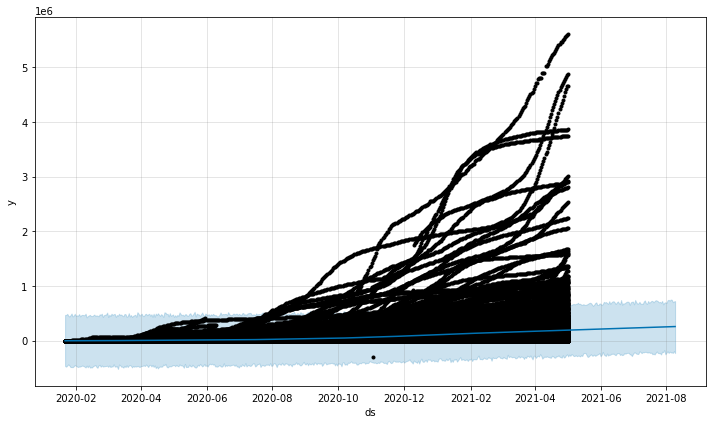

In [ ]:
fig1 =prophet_basic.plot(forecast)

Figure(720x432)


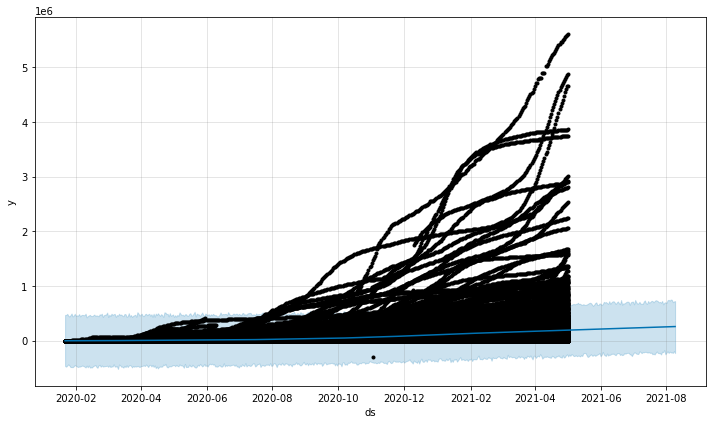

In [ ]:
print(prophet_basic.plot(forecast))

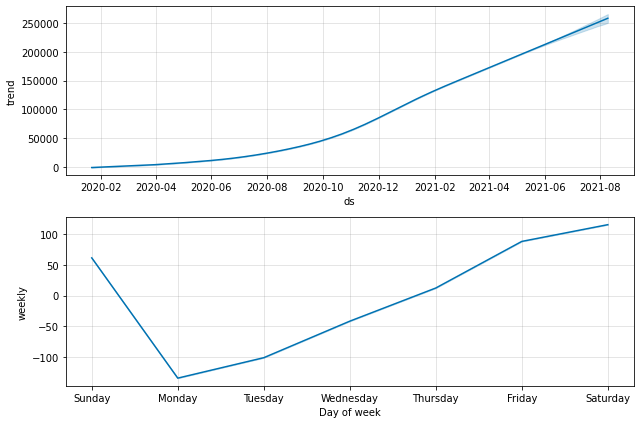

In [ ]:
fig1 = prophet_basic.plot_components(forecast)

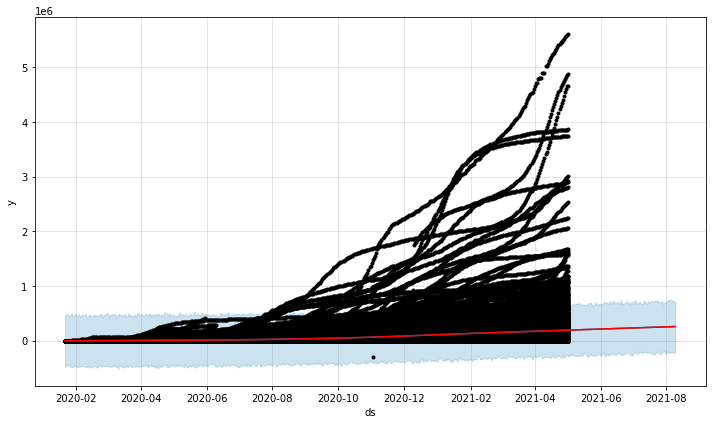

In [ ]:
from fbprophet.plot import add_changepoints_to_plot
fig = prophet_basic.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), prophet_basic, forecast)


In [ ]:
rmse_prophet=np.sqrt(mean_squared_error(india_datewise["Confirmed"],forecast['yhat'].head(india_datewise.shape[0])))
model_scores.append(rmse_prophet)
print("Root Mean Squared Error for Prophet Model: ",rmse_prophet)

Root Mean Squared Error for Prophet Model:  7539677.459757347


In [ ]:
rmspe = (np.sqrt(np.mean(np.square((india_datewise['Confirmed'] - forecast['yhat']) / india_datewise['Confirmed']))))*100
model_scores.append(rmspe)
rmspe

nan

In [ ]:
model_predictions["Prophet's Prediction"]=list(forecast["yhat"].tail(99))
model_predictions.tail(10)

,Date,Polynomial Regression Prediction,SVM Prediction,AR Model Prediction,MA Model Prediction,ARIMA Model Prediction,Prophet's Prediction,Prophet's Upper Bound
89,2021-07-31,1.008490e+08,5.842562e+07,3.050557e+07,3.553037e+07,3.138943e+07,252596.750744,703630.720592
90,2021-08-01,1.028079e+08,5.913766e+07,3.067656e+07,3.577083e+07,3.157770e+07,253204.218716,688773.057117
91,2021-08-02,1.048001e+08,5.985751e+07,3.084787e+07,3.601204e+07,3.176646e+07,253669.577451,739103.222850
92,2021-08-03,1.068259e+08,6.058526e+07,3.101949e+07,3.625400e+07,3.195569e+07,254364.581323,747373.788717
93,2021-08-04,1.088858e+08,6.132098e+07,3.119142e+07,3.649670e+07,3.214540e+07,255085.841861,732774.958903
94,2021-08-05,1.109802e+08,6.206475e+07,3.136367e+07,3.674015e+07,3.233559e+07,255801.624822,754099.467514
95,2021-08-06,1.131096e+08,6.281662e+07,3.153623e+07,3.698434e+07,3.252626e+07,256539.345729,746635.377617
96,2021-08-07,1.152742e+08,6.357668e+07,3.170910e+07,3.722928e+07,3.271741e+07,257228.326406,703495.065320
97,2021-08-08,1.174747e+08,6.434501e+07,3.188229e+07,3.747497e+07,3.290904e+07,257835.794378,718675.963508
98,2021-08-09,1.197114e+08,6.512167e+07,3.205579e+07,3.772140e+07,3.310114e+07,258301.153113,724622.322446


In [ ]:
models=["Polynomial Regression","Support Vector Machine Regresssor","Auto Regressive Model (AR)", "Moving Average Model (MA)","ARIMA Model","Facebook's Prophet Model"]


In [ ]:
model_evaluation=pd.DataFrame(list(zip(models,model_scores)),columns=["Model Name","Root Mean Squared Error"])
model_evaluation=model_evaluation.sort_values(["Root Mean Squared Error"])
model_evaluation.style.background_gradient(cmap='Reds')

,Model Name,Root Mean Squared Error
1,Support Vector Machine Regresssor,654419.690658
0,Polynomial Regression,1072755.776258
3,Moving Average Model (MA),1718256.252491
4,ARIMA Model,1718256.252491
5,Facebook's Prophet Model,1718256.252491
2,Auto Regressive Model (AR),1989891.093582
